In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/SHA256SUMS.txt
/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/RECORDS
/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/example_physionet.py
/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/scp_statements.csv
/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/ptbxl_database.csv
/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/LICENSE.txt
/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/records500/21000/21240_hr.hea
/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-p

In [ ]:
!ls -lah /kaggle/input/

In [ ]:
!ls -lah /kaggle/input/datasets/

In [ ]:
!ls -la /kaggle/input/datasets/khyeh0719/

In [ ]:

!ls -lah /kaggle/input/datasets/khyeh0719/ptb-xl-dataset

In [ ]:
#verify content of dataset
DATA_DIR = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"

!ls -lah "$DATA_DIR"

In [1]:
#check gpu
!nvidia-smi

Tue Oct  6 14:43:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/shri004/ecg-rag-research.git

Cloning into 'ecg-rag-research'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 30 (delta 4), reused 29 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 20.25 KiB | 4.05 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [3]:
%cd /kaggle/working/ecg-rag-research
!ls

/kaggle/working/ecg-rag-research
configs  eval  kb	  paper  README.md	   results  tests
docs	 gui   notebooks  rag	 requirements.txt  src


In [4]:
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.8 MB/s eta 0:00:00


In [5]:
import wfdb, pandas as pd, numpy as np
print("Dependencies ready")

Dependencies ready


In [6]:
!ls src

data_prep.py  model.py	train.py


In [ ]:
!python src/data_prep.py --help

In [7]:
DATA_DIR="/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"

!python src/data_prep.py \
  --data-dir "$DATA_DIR" \
  --out-dir "/kaggle/working/processed" \
  --sampling-rate 100

Dropped 407 records with no diagnostic superclass label
Remaining records: 21430
Train/val/test sizes: 17111/2156/2163
Saved processed arrays to /kaggle/working/processed


In [8]:
!python src/train.py --data-dir /kaggle/working/processed --epochs 30

Using device: cuda
Epoch 1/30 | train_loss=0.3531 | val_macro_auc=0.8859
  -> new best, saved checkpoint (val_macro_auc=0.8859)
Epoch 2/30 | train_loss=0.2961 | val_macro_auc=0.9072
  -> new best, saved checkpoint (val_macro_auc=0.9072)
Epoch 3/30 | train_loss=0.2786 | val_macro_auc=0.9168
  -> new best, saved checkpoint (val_macro_auc=0.9168)
Epoch 4/30 | train_loss=0.2698 | val_macro_auc=0.9215
  -> new best, saved checkpoint (val_macro_auc=0.9215)
Epoch 5/30 | train_loss=0.2631 | val_macro_auc=0.9219
  -> new best, saved checkpoint (val_macro_auc=0.9219)
Epoch 6/30 | train_loss=0.2566 | val_macro_auc=0.9225
  -> new best, saved checkpoint (val_macro_auc=0.9225)
Epoch 7/30 | train_loss=0.2542 | val_macro_auc=0.9273
  -> new best, saved checkpoint (val_macro_auc=0.9273)
Epoch 8/30 | train_loss=0.2476 | val_macro_auc=0.9207
Epoch 9/30 | train_loss=0.2443 | val_macro_auc=0.9260
Epoch 10/30 | train_loss=0.2404 | val_macro_auc=0.9224
Epoch 11/30 | train_loss=0.2372 | val_macro_auc=0.9264


In [12]:
!python src/train.py --data-dir /kaggle/working/processed --epochs 25

Using device: cuda
Epoch 1/25 | train_loss=0.3506 | val_macro_auc=0.8958
  -> new best, saved checkpoint (val_macro_auc=0.8958)
Epoch 2/25 | train_loss=0.2964 | val_macro_auc=0.9041
  -> new best, saved checkpoint (val_macro_auc=0.9041)
Epoch 3/25 | train_loss=0.2780 | val_macro_auc=0.9161
  -> new best, saved checkpoint (val_macro_auc=0.9161)
Epoch 4/25 | train_loss=0.2688 | val_macro_auc=0.9194
  -> new best, saved checkpoint (val_macro_auc=0.9194)
Epoch 5/25 | train_loss=0.2632 | val_macro_auc=0.9187
Epoch 6/25 | train_loss=0.2582 | val_macro_auc=0.9226
  -> new best, saved checkpoint (val_macro_auc=0.9226)
Epoch 7/25 | train_loss=0.2523 | val_macro_auc=0.9266
  -> new best, saved checkpoint (val_macro_auc=0.9266)
Epoch 8/25 | train_loss=0.2473 | val_macro_auc=0.9236
Epoch 9/25 | train_loss=0.2458 | val_macro_auc=0.9185
Epoch 10/25 | train_loss=0.2421 | val_macro_auc=0.9267
  -> new best, saved checkpoint (val_macro_auc=0.9267)
Epoch 11/25 | train_loss=0.2378 | val_macro_auc=0.9253


In [9]:
!pwd
!ls -lh best_model.pt
!ls -lh /kaggle/working/processed

/kaggle/working/ecg-rag-research
-rw-r--r-- 1 root root 2.0M Oct  6 15:08 best_model.pt
total 2.0G
-rw-r--r-- 1 root root 199M Oct  6 15:00 X_test.npy
-rw-r--r-- 1 root root 1.6G Oct  6 15:00 X_train.npy
-rw-r--r-- 1 root root 198M Oct  6 15:00 X_val.npy
-rw-r--r-- 1 root root  47K Oct  6 15:00 y_test.pkl
-rw-r--r-- 1 root root 366K Oct  6 15:00 y_train.pkl
-rw-r--r-- 1 root root  47K Oct  6 15:00 y_val.pkl


In [10]:
!mkdir -p checkpoints
!cp -f best_model.pt checkpoints/resnet_best.pt
!ls -lh checkpoints

total 2.0M
-rw-r--r-- 1 root root 2.0M Oct  6 15:24 resnet_best.pt


In [11]:
import torch
import os

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Checkpoint exists:", os.path.exists("checkpoints/resnet_best.pt"))
print("Checkpoint size:",
      round(os.path.getsize("checkpoints/resnet_best.pt") / (1024**2), 2),
      "MB")

CUDA available: True
Device: Tesla T4
Checkpoint exists: True
Checkpoint size: 1.97 MB


In [12]:
import os
import json
import numpy as np
import pandas as pd
import torch

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    multilabel_confusion_matrix,
)

from src.model import ResNet1d


# --------------------------------------------------
# Configuration
# --------------------------------------------------

DATA_DIR = "/kaggle/working/processed"
CHECKPOINT = "/kaggle/working/ecg-rag-research/checkpoints/resnet_best.pt"
OUT_DIR = "/kaggle/working/ecg-rag-research/results/module1"

CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]

os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


# --------------------------------------------------
# Load test data
# --------------------------------------------------

X_test = np.load(
    os.path.join(DATA_DIR, "X_test.npy"),
    mmap_mode="r"
)

y_test_raw = pd.read_pickle(
    os.path.join(DATA_DIR, "y_test.pkl")
)

print("Test ECG shape:", X_test.shape)
print("Number of test records:", len(y_test_raw))


# --------------------------------------------------
# Convert labels
# --------------------------------------------------

mlb = MultiLabelBinarizer(classes=CLASSES)
mlb.fit([CLASSES])

y_test = mlb.transform(y_test_raw).astype(np.float32)

print("Label shape:", y_test.shape)


# --------------------------------------------------
# Dataset
# --------------------------------------------------

class ECGTestDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        # Original shape: (T, C)
        # Model expects:   (C, T)

        x = torch.from_numpy(
            np.asarray(self.X[idx], dtype=np.float32)
        ).permute(1, 0)

        y = torch.from_numpy(self.y[idx])

        return x, y


test_dataset = ECGTestDataset(X_test, y_test)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)


# --------------------------------------------------
# Load model
# --------------------------------------------------

model = ResNet1d(
    in_channels=X_test.shape[2],
    num_classes=len(CLASSES)
)

checkpoint = torch.load(
    CHECKPOINT,
    map_location=device
)

model.load_state_dict(checkpoint)
model.to(device)
model.eval()

print("Checkpoint loaded successfully.")


# --------------------------------------------------
# Test inference
# --------------------------------------------------

all_probs = []
all_targets = []

with torch.no_grad():

    for batch_idx, (xb, yb) in enumerate(test_loader):

        xb = xb.to(device, non_blocking=True)

        logits = model(xb)

        probs = torch.sigmoid(logits)

        all_probs.append(
            probs.cpu().numpy()
        )

        all_targets.append(
            yb.numpy()
        )

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Processed "
                f"{min((batch_idx + 1) * 64, len(test_dataset))}"
                f"/{len(test_dataset)} test records"
            )


y_prob = np.concatenate(all_probs, axis=0)
y_true = np.concatenate(all_targets, axis=0)

y_pred = (y_prob >= 0.5).astype(int)

print("Inference complete.")
print("Predictions shape:", y_prob.shape)


# --------------------------------------------------
# Overall metrics
# --------------------------------------------------

class_auc = {}

for i, class_name in enumerate(CLASSES):

    try:
        class_auc[class_name] = float(
            roc_auc_score(
                y_true[:, i],
                y_prob[:, i]
            )
        )
    except ValueError:
        class_auc[class_name] = None


valid_aucs = [
    value for value in class_auc.values()
    if value is not None
]

macro_auc = float(np.mean(valid_aucs))

macro_f1 = float(
    f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)

micro_f1 = float(
    f1_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    )
)

macro_precision = float(
    precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)

macro_recall = float(
    recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)


# --------------------------------------------------
# Class-wise metrics
# --------------------------------------------------

class_f1 = f1_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

class_precision = precision_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

class_recall = recall_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

class_metrics = {}

for i, class_name in enumerate(CLASSES):

    class_metrics[class_name] = {
        "precision": float(class_precision[i]),
        "recall": float(class_recall[i]),
        "f1": float(class_f1[i]),
        "auroc": class_auc[class_name]
    }


# --------------------------------------------------
# Confusion matrices
# --------------------------------------------------

cm = multilabel_confusion_matrix(
    y_true,
    y_pred
)

confusion_matrices = {}

for i, class_name in enumerate(CLASSES):

    confusion_matrices[class_name] = cm[i].tolist()


# --------------------------------------------------
# Save predictions
# --------------------------------------------------

np.save(
    os.path.join(OUT_DIR, "test_probabilities.npy"),
    y_prob
)

np.save(
    os.path.join(OUT_DIR, "test_predictions.npy"),
    y_pred
)

np.save(
    os.path.join(OUT_DIR, "test_targets.npy"),
    y_true
)


# --------------------------------------------------
# Save evaluation summary
# --------------------------------------------------

results = {
    "dataset": "PTB-XL",
    "split": "official test split",
    "num_test_records": int(len(y_true)),
    "classes": CLASSES,
    "checkpoint": CHECKPOINT,

    "overall": {
        "macro_auroc": macro_auc,
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall
    },

    "class_wise": class_metrics,

    "confusion_matrices": confusion_matrices
}


summary_path = os.path.join(
    OUT_DIR,
    "evaluation_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(results, f, indent=2)


# --------------------------------------------------
# Print final results
# --------------------------------------------------

print("\n" + "=" * 55)
print("FINAL TEST RESULTS")
print("=" * 55)

print(f"Macro AUROC : {macro_auc:.4f}")
print(f"Macro F1    : {macro_f1:.4f}")
print(f"Micro F1    : {micro_f1:.4f}")
print(f"Macro Prec. : {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")

print("\nClass-wise results:")

for class_name in CLASSES:

    m = class_metrics[class_name]

    print(
        f"{class_name:5s} | "
        f"Precision={m['precision']:.4f} | "
        f"Recall={m['recall']:.4f} | "
        f"F1={m['f1']:.4f} | "
        f"AUROC={m['auroc']:.4f}"
    )

print("\nSaved:")
print(summary_path)

Device: cuda
GPU: Tesla T4
Test ECG shape: (2163, 1000, 12)
Number of test records: 2163
Label shape: (2163, 5)
Checkpoint loaded successfully.
Processed 640/2163 test records
Processed 1280/2163 test records
Processed 1920/2163 test records
Inference complete.
Predictions shape: (2163, 5)

FINAL TEST RESULTS
Macro AUROC : 0.9276
Macro F1    : 0.7186
Micro F1    : 0.7712
Macro Prec. : 0.8174
Macro Recall: 0.6636

Class-wise results:
NORM  | Precision=0.8083 | Recall=0.9139 | F1=0.8578 | AUROC=0.9475
MI    | Precision=0.8172 | Recall=0.6709 | F1=0.7368 | AUROC=0.9355
STTC  | Precision=0.8079 | Recall=0.7075 | F1=0.7543 | AUROC=0.9334
CD    | Precision=0.8487 | Recall=0.6647 | F1=0.7455 | AUROC=0.9233
HYP   | Precision=0.8051 | Recall=0.3612 | F1=0.4987 | AUROC=0.8986

Saved:
/kaggle/working/ecg-rag-research/results/module1/evaluation_summary.json


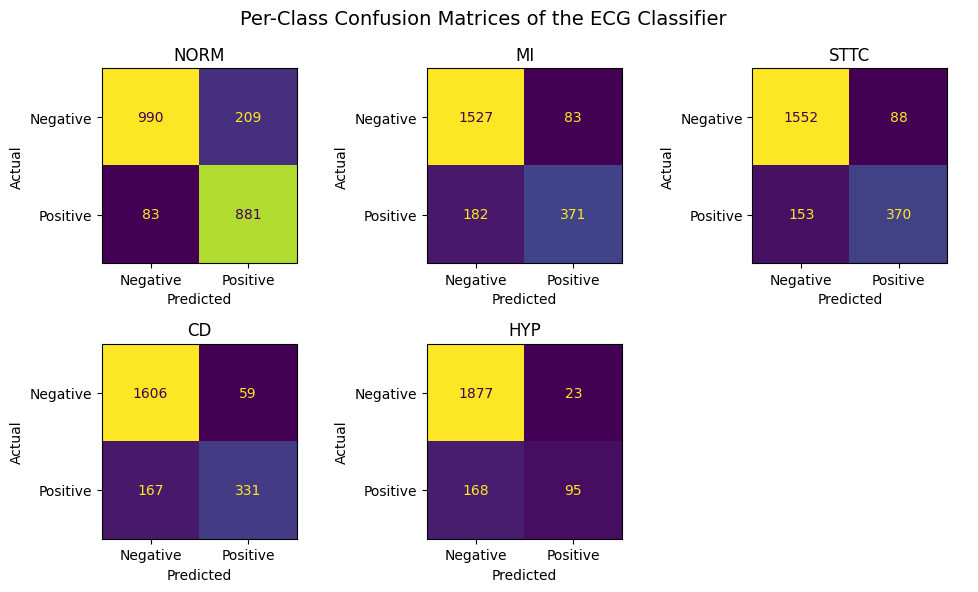

Saved: /kaggle/working/ecg-rag-research/results/module1/figure4_confusion_matrices.png


In [13]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

OUT_DIR = "/kaggle/working/ecg-rag-research/results/module1"

with open(os.path.join(OUT_DIR, "evaluation_summary.json")) as f:
    results = json.load(f)

classes = results["classes"]
cms = results["confusion_matrices"]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))

axes = axes.flatten()

for i, class_name in enumerate(classes):
    cm = np.array(cms[class_name])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot(
        ax=axes[i],
        colorbar=False
    )

    axes[i].set_title(class_name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Hide unused sixth panel
axes[5].axis("off")

fig.suptitle(
    "Per-Class Confusion Matrices of the ECG Classifier",
    fontsize=14
)

plt.tight_layout()

figure_path = os.path.join(
    OUT_DIR,
    "figure4_confusion_matrices.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

In [14]:
!cd /kaggle/working/ecg-rag-research && \
tar -czf /kaggle/working/module1_final_backup.tar.gz \
    checkpoints/resnet_best.pt \
    results/module1/evaluation_summary.json \
    results/module1/test_probabilities.npy \
    results/module1/test_predictions.npy \
    results/module1/test_targets.npy \
    results/module1/figure4_confusion_matrices.png

!ls -lh /kaggle/working/module1_final_backup.tar.gz

-rw-r--r-- 1 root root 2.0M Oct  6 15:31 /kaggle/working/module1_final_backup.tar.gz


In [16]:
from pathlib import Path
import json

repo = Path("/kaggle/working/ecg-rag-research")
results_dir = repo / "results" / "module1"
results_dir.mkdir(parents=True, exist_ok=True)

summary = {
    "dataset": "PTB-XL",
    "task": "Diagnostic superclass multi-label classification",
    "sampling_rate_hz": 100,
    "records_after_filtering": 21430,
    "records_dropped_missing_diagnostic_superclass": 407,
    "train_records": 17111,
    "validation_records": 2156,
    "test_records": 2163,
    "split": {
        "train": "PTB-XL folds 1-8",
        "validation": "PTB-XL fold 9",
        "test": "PTB-XL fold 10"
    },
    "model": "ResNet1D-Wang",
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "epochs": 30,
    "batch_size": 64,
    "best_validation_macro_auroc": 0.9284,
    "best_validation_epoch": 13,
    "test_metrics": {
        "macro_auroc": 0.9276,
        "macro_f1": 0.7186,
        "micro_f1": 0.7712,
        "macro_precision": 0.8174,
        "macro_recall": 0.6636
    },
    "checkpoint": "checkpoints/resnet_best.pt",
    "status": "Module 1 complete"
}

path = results_dir / "module1_results.json"

with open(path, "w") as f:
    json.dump(summary, f, indent=2)

print(path)

/kaggle/working/ecg-rag-research/results/module1/module1_results.json


In [17]:
from IPython.display import FileLink

FileLink("/kaggle/working/module1_final_backup.tar.gz")

/kaggle/working/module1_final_backup.tar.gz

In [ ]:
!ls src

In [ ]:
#inspect what train.py saves
!sed -n '1,260p' src/train.py

In [ ]:
#check whee chekpoint is saved
!find . -name "*.pt" -o -name "*.pth"

In [15]:

# creating evaluate.py

code = r'''
import argparse
import os
import json

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import MultiLabelBinarizer
from tqdm.auto import tqdm

from model import ResNet1d


CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]


def load_split(data_dir, split):
    X = np.load(os.path.join(data_dir, f"X_{split}.npy"))
    y = pd.read_pickle(os.path.join(data_dir, f"y_{split}.pkl"))
    return X, y


def main(data_dir, checkpoint, out_dir):

    os.makedirs(out_dir, exist_ok=True)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Load test data
    X_test, y_test_raw = load_split(data_dir, "test")

    # Prepare labels
    mlb = MultiLabelBinarizer(classes=CLASSES)
    mlb.fit([CLASSES])

    # Convert ECG shape:
    # (N, T, C) -> (N, C, T)
    X_test_t = torch.tensor(
        X_test,
        dtype=torch.float32
    ).permute(0, 2, 1)

    y_true = mlb.transform(y_test_raw)

    # Recreate model
    model = ResNet1d(
        in_channels=X_test_t.shape[1],
        num_classes=len(CLASSES)
    ).to(device)

    # Load saved best checkpoint
    model.load_state_dict(
        torch.load(
            checkpoint,
            map_location=device
        )
    )

    model.eval()

    all_probs = []
    batch_size = 64

    # Run predictions
    with torch.no_grad():

        for i in tqdm(
            range(0, len(X_test_t), batch_size),
            desc="Evaluating"
        ):

            xb = X_test_t[
                i:i + batch_size
            ].to(device)

            probs = torch.sigmoid(
                model(xb)
            ).cpu().numpy()

            all_probs.append(probs)

    # Combine predictions from all batches
    y_prob = np.concatenate(all_probs)

    # Calculate per-class AUC
    per_class_auc = {}

    for i, class_name in enumerate(CLASSES):

        if y_true[:, i].sum() > 0:

            auc = roc_auc_score(
                y_true[:, i],
                y_prob[:, i]
            )

            per_class_auc[class_name] = float(auc)

    # Macro average AUC
    macro_auc = float(
        np.mean(
            list(per_class_auc.values())
        )
    )

    # Convert probabilities to binary predictions
    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    # Macro F1 score
    macro_f1 = float(
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    # Print results
    print("\n===== TEST RESULTS =====")

    print(
        f"Test Macro-AUC: {macro_auc:.4f}"
    )

    print(
        f"Test Macro-F1:  {macro_f1:.4f}"
    )

    print("\nPer-class AUC:")

    for class_name, auc in per_class_auc.items():

        print(
            f"{class_name}: {auc:.4f}"
        )

    # Save results
    results = {
        "test_macro_auc": macro_auc,
        "test_macro_f1": macro_f1,
        "per_class_auc": per_class_auc
    }

    output_path = os.path.join(
        out_dir,
        "evaluation_summary.json"
    )

    with open(output_path, "w") as f:

        json.dump(
            results,
            f,
            indent=4
        )

    print(
        f"\nSaved results to {output_path}"
    )


if __name__ == "__main__":

    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--data-dir",
        required=True
    )

    parser.add_argument(
        "--checkpoint",
        required=True
    )

    parser.add_argument(
        "--out-dir",
        default="results/module1"
    )

    args = parser.parse_args()

    main(
        args.data_dir,
        args.checkpoint,
        args.out_dir
    )
'''

with open("src/evaluate.py", "w") as f:
    f.write(code)

print("evaluate.py created successfully")
 
    

evaluate.py created successfully


In [ ]:
#evaluate the saved best model, 
!python src/evaluate.py \
  --data-dir /kaggle/working/processed \
  --checkpoint best_model.pt \
  --out-dir results/module1

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

In [ ]:
!ls -lh best_model.pt
!ls /kaggle/working/processed | head

In [ ]:
!pwd
!ls -la /kaggle/working

In [ ]:
!ls /kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1

In [ ]:
%cd /kaggle/working
!git clone https://github.com/shri004/ecg-rag-research.git
%cd /kaggle/working/ecg-rag-research
!ls

In [ ]:
!find /kaggle/input -name "best_model.pt" -o -name "evaluation_summary.json" 2>/dev/null

In [ ]:
!ls -la /kaggle/input

In [ ]:
!find /kaggle/input/datasets -maxdepth 4 -type f -name "best_model.pt" 2>/dev/null

In [2]:
!pwd

!echo "=== CHECKPOINT ==="
!ls -lh /kaggle/working/ecg-rag-research/best_model.pt 2>/dev/null || echo "checkpoint missing"

!echo "=== PROCESSED DATA ==="
!ls -lh /kaggle/working/processed 2>/dev/null || echo "processed missing"

!echo "=== REPO ==="
!ls -lh /kaggle/working/ecg-rag-research 2>/dev/null || echo "repo missing"

/kaggle/working
=== CHECKPOINT ===
checkpoint missing
=== PROCESSED DATA ===
processed missing
=== REPO ===
repo missing
